In [1]:
# Import libraries
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("data.csv")

# Display first rows
df.head()

,RegionCode,RegionName,CountryCode,CountryName,Year,Sex,AgeGroup,Generation,SuicideCount,CauseSpecificDeathPercentage,DeathRatePer100K,Population,GDP,GDPPerCapita,InflationRate,EmploymentPopulationRatio
0,EU,Europe,ALB,Albania,1992,Male,0-14 years,Generation Alpha,0.0,0.000000,0.000000,3247039.0,652174990.8,200.85222,226.005421,45.315
1,EU,Europe,ALB,Albania,1992,Male,0-14 years,Generation Alpha,0.0,0.000000,0.000000,3247039.0,652174990.8,200.85222,226.005421,45.315
2,EU,Europe,ALB,Albania,1992,Male,0-14 years,Generation Alpha,0.0,0.000000,0.000000,3247039.0,652174990.8,200.85222,226.005421,45.315
3,EU,Europe,ALB,Albania,1992,Male,0-14 years,Generation Alpha,0.0,0.000000,0.000000,3247039.0,652174990.8,200.85222,226.005421,45.315
4,EU,Europe,ALB,Albania,1992,Male,15-24 years,Generation Z,5.0,3.401361,3.531073,3247039.0,652174990.8,200.85222,226.005421,45.315


In [2]:
# Check missing values
#handling missing value
df.isnull().sum()

RegionCode                          0
RegionName                          0
CountryCode                         0
CountryName                         0
Year                                0
Sex                                 0
AgeGroup                            0
Generation                          0
SuicideCount                      464
CauseSpecificDeathPercentage     4289
DeathRatePer100K                10664
Population                       5920
GDP                              7240
GDPPerCapita                     7240
InflationRate                   14460
EmploymentPopulationRatio       11120
dtype: int64

In [3]:
# Fill missing values with mean (for numerical columns)
df.fillna(df.mean(numeric_only=True), inplace=True)

# For categorical columns (if any missing)
df.fillna("Unknown", inplace=True)

In [4]:
# Check duplicates
#remove duplicates
df.duplicated().sum()

# Drop duplicates
df.drop_duplicates(inplace=True)

In [5]:
# Check datatypes
df.dtypes

# Example: Convert Year to int (if needed)
df['Year'] = df['Year'].astype(int)

In [6]:
#EDA data analysis
# Dataset info
df.info()
# Missing values
df.isnull().sum()
# Summary statistics
df.describe()
# Unique countries
df['CountryName'].nunique()
# Unique years
df['Year'].unique()

<class 'pandas.core.frame.DataFrame'>
Index: 95976 entries, 0 to 118559
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   RegionCode                    95976 non-null  object 
 1   RegionName                    95976 non-null  object 
 2   CountryCode                   95976 non-null  object 
 3   CountryName                   95976 non-null  object 
 4   Year                          95976 non-null  int64  
 5   Sex                           95976 non-null  object 
 6   AgeGroup                      95976 non-null  object 
 7   Generation                    95976 non-null  object 
 8   SuicideCount                  95976 non-null  float64
 9   CauseSpecificDeathPercentage  95976 non-null  float64
 10  DeathRatePer100K              95976 non-null  float64
 11  Population                    95976 non-null  float64
 12  GDP                           95976 non-null  float64
 13  GDPPe

array([1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002,
       2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 1991, 2011, 2012,
       2013, 2014, 1990, 2020, 2019, 2018, 2017, 2016, 2015, 2021, 2022])

In [7]:
# Selecting important columns
df_selected = df[['Year', 'CountryName', 'Sex', 'AgeGroup',
                  'SuicideCount', 'DeathRatePer100K',
                  'GDPPerCapita', 'Population']]

In [8]:
# Total suicides per year
yearly_suicides = df.groupby('Year')['SuicideCount'].sum()

# Average suicide rate per year
avg_rate = df.groupby('Year')['DeathRatePer100K'].mean()

In [9]:
# Highest suicide year
yearly_suicides.idxmax()

# Lowest suicide year
yearly_suicides.idxmin()

np.int64(2022)

In [10]:
import matplotlib.pyplot as plt

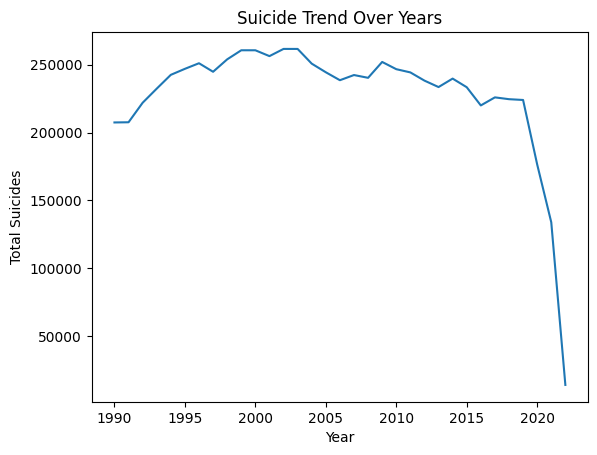

In [11]:
#data visualisation
#Line plot 
plt.figure()
yearly_suicides.plot()
plt.title("Suicide Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Total Suicides")
plt.show()

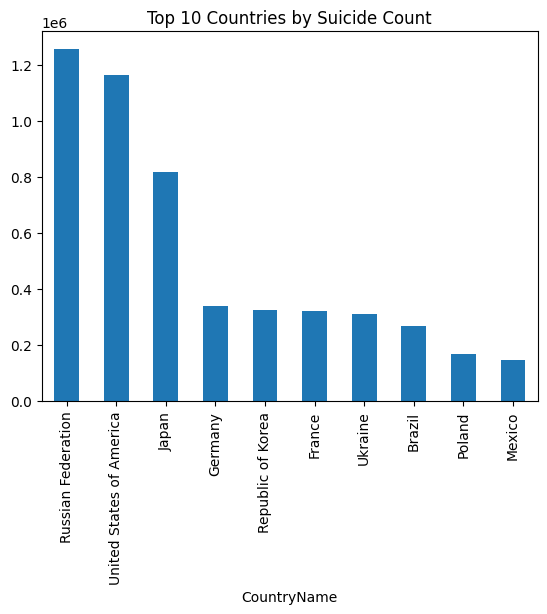

In [12]:
top_countries = df.groupby('CountryName')['SuicideCount'].sum().sort_values(ascending=False).head(10)

plt.figure()
top_countries.plot(kind='bar')
plt.title("Top 10 Countries by Suicide Count")
plt.show()   # bar graph

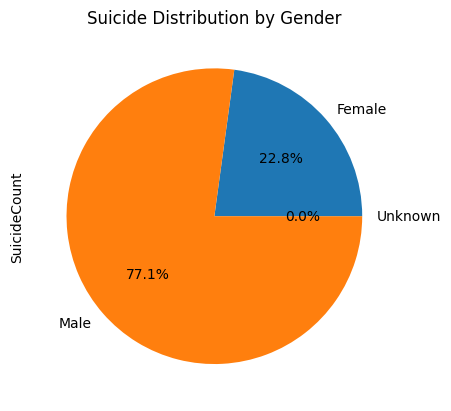

In [13]:
gender_data = df.groupby('Sex')['SuicideCount'].sum()

plt.figure()
gender_data.plot(kind='pie', autopct='%1.1f%%')
plt.title("Suicide Distribution by Gender")
plt.show()  #pie chart

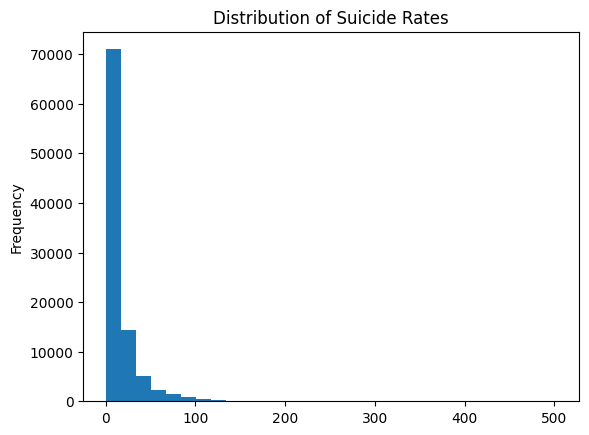

In [14]:
plt.figure()
df['DeathRatePer100K'].plot(kind='hist', bins=30)
plt.title("Distribution of Suicide Rates")
plt.show()   #histogram

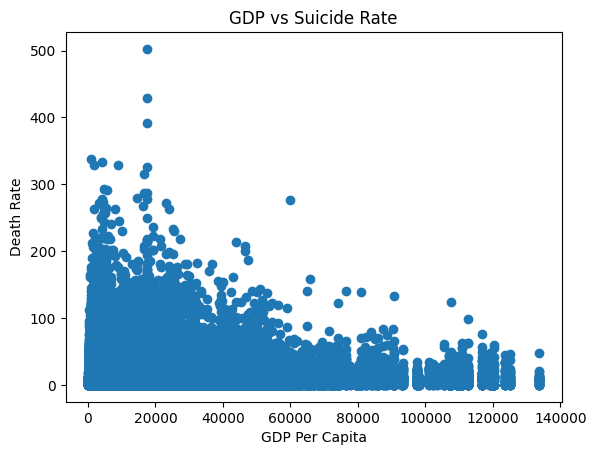

In [15]:
plt.figure()
plt.scatter(df['GDPPerCapita'], df['DeathRatePer100K'])
plt.xlabel("GDP Per Capita")
plt.ylabel("Death Rate")
plt.title("GDP vs Suicide Rate")
plt.show()  #scatter plot 

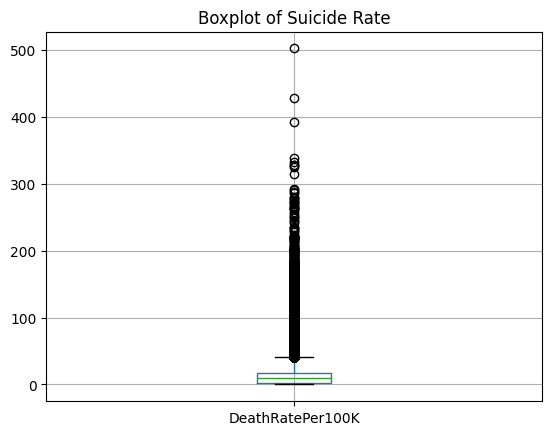

In [16]:
plt.figure()
df.boxplot(column='DeathRatePer100K')
plt.title("Boxplot of Suicide Rate")
plt.show()  #box plot

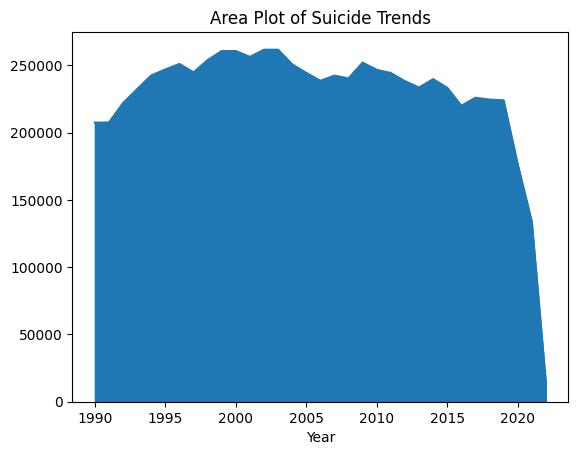

In [17]:
yearly_suicides.plot.area()
plt.title("Area Plot of Suicide Trends")
plt.show() #area plot

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

In [19]:
# Select only numerical columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Display columns
numeric_df.columns

Index(['Year', 'SuicideCount', 'CauseSpecificDeathPercentage',
       'DeathRatePer100K', 'Population', 'GDP', 'GDPPerCapita',
       'InflationRate', 'EmploymentPopulationRatio'],
      dtype='object')

In [20]:
# Correlation matrix
corr_matrix = numeric_df.corr()

# Display it
corr_matrix

,Year,SuicideCount,CauseSpecificDeathPercentage,DeathRatePer100K,Population,GDP,GDPPerCapita,InflationRate,EmploymentPopulationRatio
Year,1.000000,-0.016214,0.054724,-0.110367,0.042685,0.091198,0.276628,-0.139373,0.069880
SuicideCount,-0.016214,1.000000,0.121404,0.244566,0.514957,0.454234,0.074536,0.026170,0.035254
CauseSpecificDeathPercentage,0.054724,0.121404,1.000000,0.087353,-0.017161,0.064632,0.240865,-0.022818,0.046445
DeathRatePer100K,-0.110367,0.244566,0.087353,1.000000,-0.023723,0.003806,0.000610,0.041684,-0.067304
Population,0.042685,0.514957,-0.017161,-0.023723,1.000000,0.778648,0.070100,0.027706,0.053679
GDP,0.091198,0.454234,0.064632,0.003806,0.778648,1.000000,0.303445,-0.024532,0.067324
GDPPerCapita,0.276628,0.074536,0.240865,0.000610,0.070100,0.303445,1.000000,-0.078489,0.265137
InflationRate,-0.139373,0.026170,-0.022818,0.041684,0.027706,-0.024532,-0.078489,1.000000,0.018585
EmploymentPopulationRatio,0.069880,0.035254,0.046445,-0.067304,0.053679,0.067324,0.265137,0.018585,1.000000


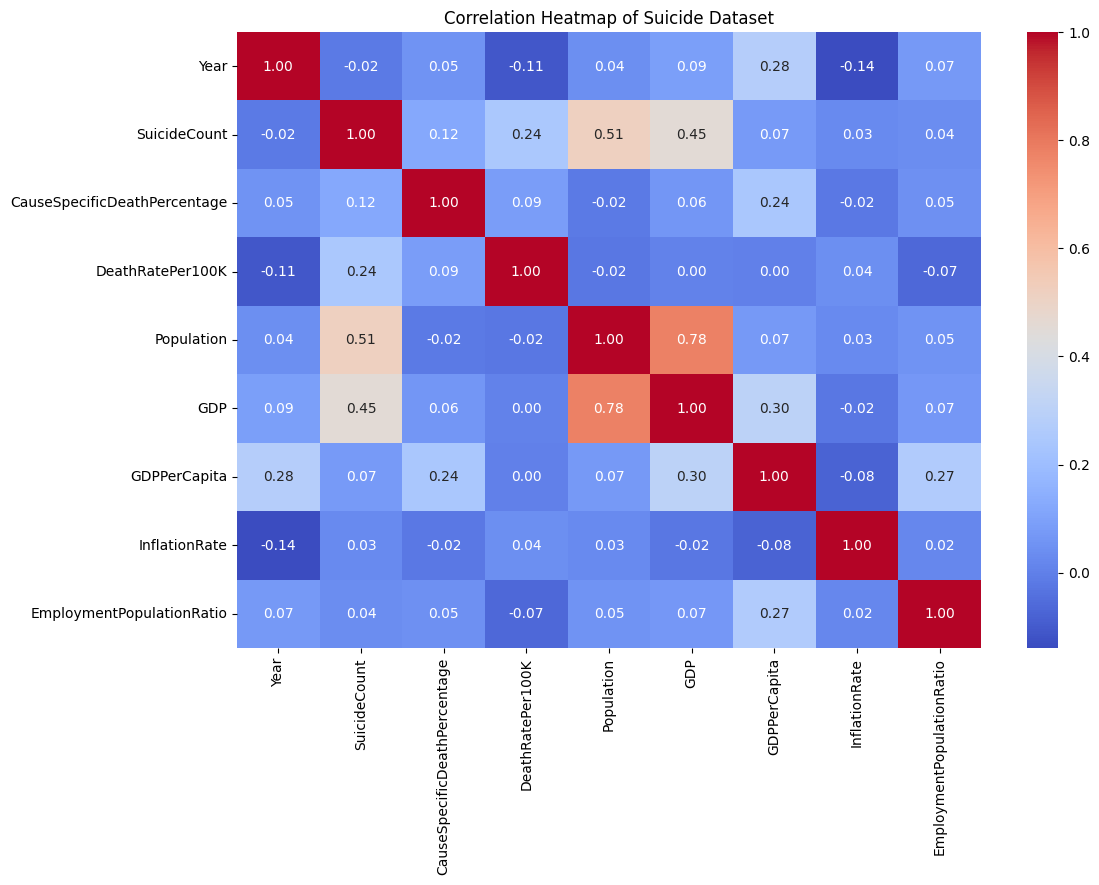

In [21]:
plt.figure(figsize=(12,8))

sns.heatmap(corr_matrix, 
            annot=True,        # show values
            fmt=".2f",         # 2 decimal places
            cmap="coolwarm")   # color style

plt.title("Correlation Heatmap of Suicide Dataset")
plt.show()  #for heat map